In [2]:
import pandas as pd

# Load final AtmoSync dataset
atmosync_df = pd.read_csv("AtmoSync_Final_Data.csv")

print("AtmoSync final dataset loaded successfully!")
print("Total records:", len(atmosync_df))
print("Total containers:", atmosync_df["Container_ID"].nunique())

display(atmosync_df.head())

AtmoSync final dataset loaded successfully!
Total records: 5000
Total containers: 100


,Container_ID,Timestamp,Temperature_C,Humidity_Percent,Latitude,Longitude
0,CONT_0024,2026-09-01 00:00:00,26.6,24,34.52,69.18
1,CONT_0066,2026-09-01 00:01:00,19.0,94,41.33,19.82
2,CONT_0042,2026-09-01 00:02:00,6.3,61,42.50,1.52
3,CONT_0043,2026-09-01 00:03:00,26.0,89,-8.84,13.23
4,CONT_0046,2026-09-01 00:04:00,19.0,40,40.18,44.51


In [3]:
# Check the structure of the final dataset

print("Dataset shape:", atmosync_df.shape)

print("\nColumn names:")
print(atmosync_df.columns.tolist())

print("\nData types:")
display(atmosync_df.dtypes)

Dataset shape: (5000, 6)

Column names:
['Container_ID', 'Timestamp', 'Temperature_C', 'Humidity_Percent', 'Latitude', 'Longitude']

Data types:


Container_ID         object
Timestamp            object
Temperature_C       float64
Humidity_Percent      int64
Latitude            float64
Longitude           float64
dtype: object

In [4]:
# Convert Timestamp to datetime format

atmosync_df["Timestamp"] = pd.to_datetime(atmosync_df["Timestamp"])

print("Timestamp converted successfully!")
print("Timestamp data type:", atmosync_df["Timestamp"].dtype)

Timestamp converted successfully!
Timestamp data type: datetime64[ns]


In [5]:
# Check for missing values and duplicate records

print("Missing values:")
display(atmosync_df.isnull().sum())

print("\nDuplicate records:", atmosync_df.duplicated().sum())

Missing values:


Container_ID        0
Timestamp           0
Temperature_C       0
Humidity_Percent    0
Latitude            0
Longitude           0
dtype: int64


Duplicate records: 0


In [6]:
# Overall temperature analysis

average_temp = atmosync_df["Temperature_C"].mean()
minimum_temp = atmosync_df["Temperature_C"].min()
maximum_temp = atmosync_df["Temperature_C"].max()

print("Temperature Analysis")
print("--------------------")
print("Average Temperature:", round(average_temp, 2), "°C")
print("Minimum Temperature:", minimum_temp, "°C")
print("Maximum Temperature:", maximum_temp, "°C")

Temperature Analysis
--------------------
Average Temperature: 26.37 °C
Minimum Temperature: -3.7 °C
Maximum Temperature: 49.1 °C


In [7]:
# Overall humidity analysis

average_humidity = atmosync_df["Humidity_Percent"].mean()
minimum_humidity = atmosync_df["Humidity_Percent"].min()
maximum_humidity = atmosync_df["Humidity_Percent"].max()

print("Humidity Analysis")
print("------------------")
print("Average Humidity:", round(average_humidity, 2), "%")
print("Minimum Humidity:", minimum_humidity, "%")
print("Maximum Humidity:", maximum_humidity, "%")

Humidity Analysis
------------------
Average Humidity: 55.01 %
Minimum Humidity: 3 %
Maximum Humidity: 100 %


In [8]:
# Average temperature for each container

container_temperature = (
    atmosync_df.groupby("Container_ID")["Temperature_C"]
    .mean()
    .sort_values(ascending=False)
)

print("Average temperature by container:")
display(container_temperature.head(10))

Average temperature by container:


Container_ID
CONT_0077    42.462
CONT_0013    42.170
CONT_0010    38.860
CONT_0052    38.388
CONT_0080    38.112
CONT_0040    37.000
CONT_0048    36.950
CONT_0050    36.226
CONT_0059    36.102
CONT_0062    35.528
Name: Temperature_C, dtype: float64

In [9]:
# Containers with the lowest average temperature

lowest_temperature = (
    atmosync_df.groupby("Container_ID")["Temperature_C"]
    .mean()
    .sort_values()
)

print("Lowest average temperature by container:")
display(lowest_temperature.head(10))

Lowest average temperature by container:


Container_ID
CONT_0082     3.752
CONT_0073    10.662
CONT_0091    12.712
CONT_0075    14.984
CONT_0042    15.860
CONT_0053    18.404
CONT_0019    19.342
CONT_0068    19.424
CONT_0097    19.788
CONT_0100    20.074
Name: Temperature_C, dtype: float64

In [10]:
# Average humidity for each container

container_humidity = (
    atmosync_df.groupby("Container_ID")["Humidity_Percent"]
    .mean()
    .sort_values(ascending=False)
)

print("Highest average humidity by container:")
display(container_humidity.head(10))

Highest average humidity by container:


Container_ID
CONT_0025    94.60
CONT_0082    91.72
CONT_0056    89.96
CONT_0034    89.50
CONT_0045    88.22
CONT_0031    85.64
CONT_0093    85.24
CONT_0065    84.60
CONT_0022    84.56
CONT_0003    82.80
Name: Humidity_Percent, dtype: float64

In [11]:
# Containers with the lowest average humidity

lowest_humidity = (
    atmosync_df.groupby("Container_ID")["Humidity_Percent"]
    .mean()
    .sort_values()
)

print("Lowest average humidity by container:")
display(lowest_humidity.head(10))

Lowest average humidity by container:


Container_ID
CONT_0077     5.58
CONT_0013    11.32
CONT_0098    15.12
CONT_0078    18.24
CONT_0055    19.52
CONT_0001    20.70
CONT_0028    24.34
CONT_0046    26.26
CONT_0089    27.00
CONT_0009    27.72
Name: Humidity_Percent, dtype: float64

In [12]:
# Check the relationship between temperature and humidity

correlation = atmosync_df["Temperature_C"].corr(
    atmosync_df["Humidity_Percent"]
)

print("Temperature-Humidity Correlation:", round(correlation, 2))

Temperature-Humidity Correlation: -0.47


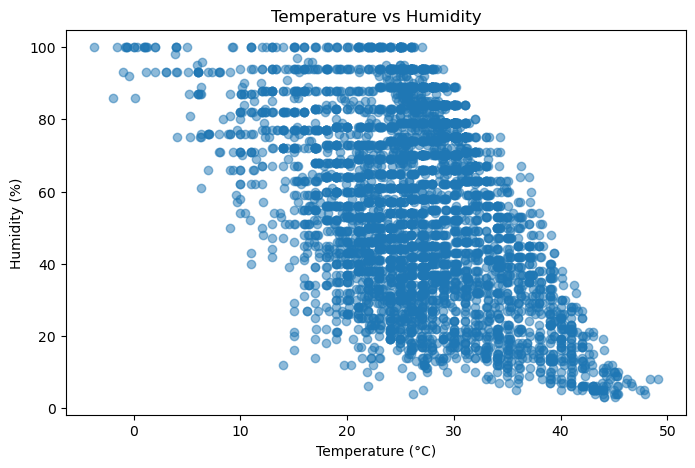

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    atmosync_df["Temperature_C"],
    atmosync_df["Humidity_Percent"],
    alpha=0.5
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")

plt.show()

In [14]:
# Average temperature by container with location

location_temperature = (
    atmosync_df.groupby("Container_ID")
    .agg({
        "Temperature_C": "mean",
        "Latitude": "first",
        "Longitude": "first"
    })
    .sort_values("Temperature_C", ascending=False)
)

print("Temperature and location details:")
display(location_temperature.head(10))

Temperature and location details:


,Temperature_C,Latitude,Longitude
Container_ID,,,
CONT_0077,42.462,24.64,46.77
CONT_0013,42.170,33.34,44.39
CONT_0010,38.860,12.11,15.05
CONT_0052,38.388,13.52,2.12
CONT_0080,38.112,28.60,77.20
CONT_0040,37.000,24.47,54.37
CONT_0048,36.950,23.61,58.59
CONT_0050,36.226,26.24,50.58
CONT_0059,36.102,12.37,-1.52


In [15]:
# Coldest containers with location details

coldest_locations = (
    atmosync_df.groupby("Container_ID")
    .agg({
        "Temperature_C": "mean",
        "Latitude": "first",
        "Longitude": "first"
    })
    .sort_values("Temperature_C")
)

print("Coldest containers and their locations:")
display(coldest_locations.head(10))

Coldest containers and their locations:


,Temperature_C,Latitude,Longitude
Container_ID,,,
CONT_0082,3.752,-35.28,149.22
CONT_0073,10.662,-41.30,174.78
CONT_0091,12.712,-34.86,-56.17
CONT_0075,14.984,47.92,106.92
CONT_0042,15.860,42.50,1.52
CONT_0053,18.404,52.37,4.89
CONT_0019,19.342,-18.92,47.52
CONT_0068,19.424,47.13,9.52
CONT_0097,19.788,48.87,2.33


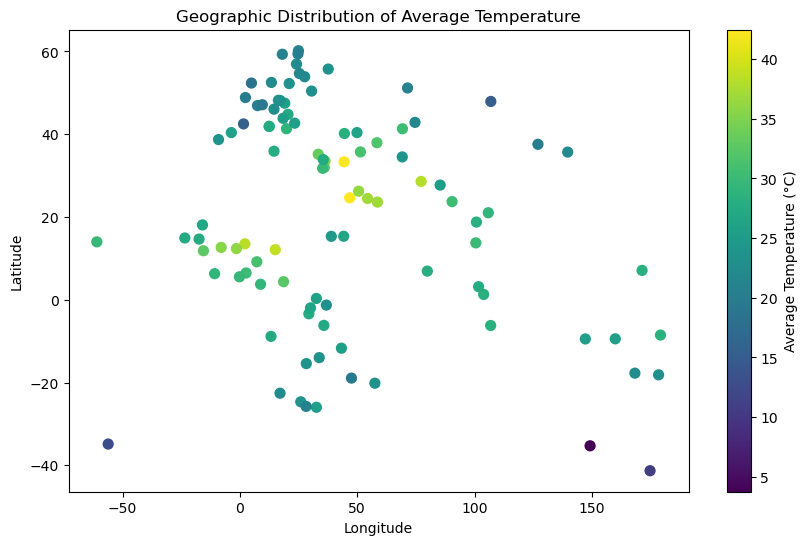

In [27]:
# Geographic distribution of average temperature

plt.figure(figsize=(10, 6))

plt.scatter(
    location_temperature["Longitude"],
    location_temperature["Latitude"],
    c=location_temperature["Temperature_C"],
    s=50
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Average Temperature")

plt.colorbar(label="Average Temperature (°C)")

plt.show()

In [28]:
# Temperature over time

time_temperature = (
    atmosync_df.groupby("Timestamp")["Temperature_C"]
    .mean()
)

print("Temperature over time:")
display(time_temperature.head(10))

Temperature over time:


Timestamp
2026-09-01 00:00:00    26.6
2026-09-01 00:01:00    19.0
2026-09-01 00:02:00     6.3
2026-09-01 00:03:00    26.0
2026-09-01 00:04:00    19.0
2026-09-01 00:05:00     9.0
2026-09-01 00:06:00    16.0
2026-09-01 00:07:00    17.0
2026-09-01 00:08:00    36.0
2026-09-01 00:09:00    38.4
Name: Temperature_C, dtype: float64

In [29]:
# Average temperature for each hour

hourly_temperature = (
    atmosync_df.set_index("Timestamp")["Temperature_C"]
    .resample("1h")
    .mean()
)

print("Hourly average temperature:")
display(hourly_temperature.head(10))

Hourly average temperature:


Timestamp
2026-09-01 00:00:00    23.785000
2026-09-01 01:00:00    23.230000
2026-09-01 02:00:00    24.771667
2026-09-01 03:00:00    24.026667
2026-09-01 04:00:00    23.441667
2026-09-01 05:00:00    26.341667
2026-09-01 06:00:00    25.218333
2026-09-01 07:00:00    25.615000
2026-09-01 08:00:00    25.398333
2026-09-01 09:00:00    24.913333
Freq: h, Name: Temperature_C, dtype: float64

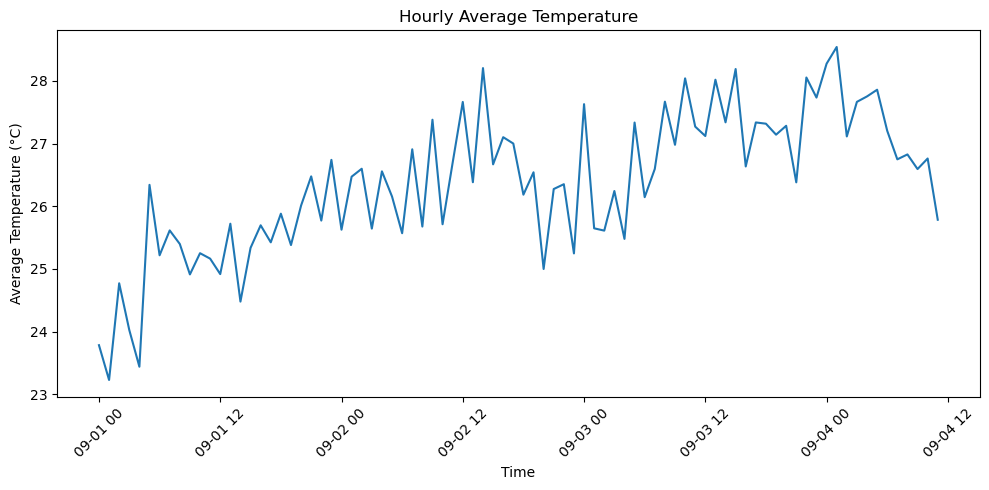

In [30]:
# Hourly temperature trend

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_temperature.index,
    hourly_temperature.values
)

plt.xlabel("Time")
plt.ylabel("Average Temperature (°C)")
plt.title("Hourly Average Temperature")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
# Hourly average humidity

hourly_humidity = (
    atmosync_df.set_index("Timestamp")["Humidity_Percent"]
    .resample("1h")
    .mean()
)

print("Hourly average humidity:")
display(hourly_humidity.head(10))

Hourly average humidity:


Timestamp
2026-09-01 00:00:00    57.416667
2026-09-01 01:00:00    60.716667
2026-09-01 02:00:00    56.633333
2026-09-01 03:00:00    56.900000
2026-09-01 04:00:00    59.283333
2026-09-01 05:00:00    51.300000
2026-09-01 06:00:00    54.800000
2026-09-01 07:00:00    55.916667
2026-09-01 08:00:00    54.933333
2026-09-01 09:00:00    57.216667
Freq: h, Name: Humidity_Percent, dtype: float64

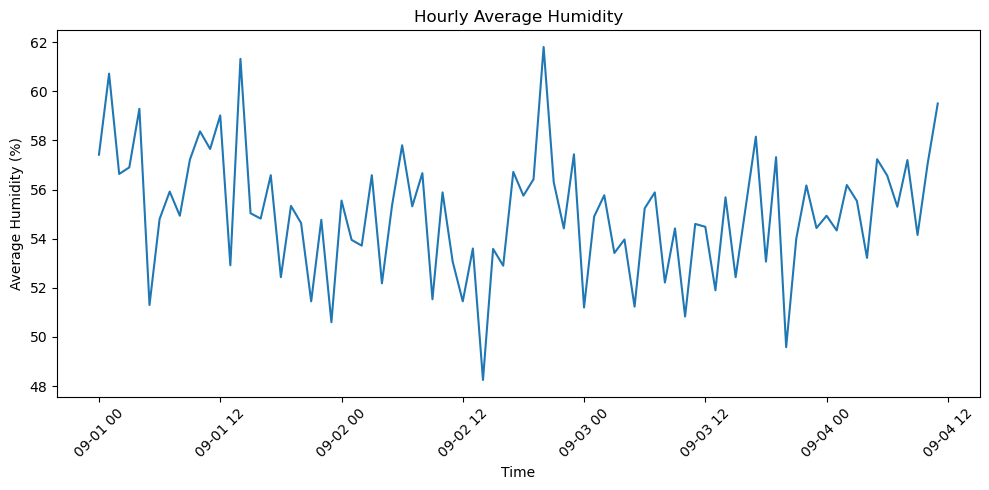

In [32]:
# Hourly humidity trend

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_humidity.index,
    hourly_humidity.values
)

plt.xlabel("Time")
plt.ylabel("Average Humidity (%)")
plt.title("Hourly Average Humidity")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
# Recreate climate profiles using the correct overall averages

climate_profile = (
    atmosync_df.groupby("Container_ID")
    .agg({
        "Temperature_C": "mean",
        "Humidity_Percent": "mean"
    })
)

climate_profile["Climate_Type"] = "Normal"

climate_profile.loc[
    (climate_profile["Temperature_C"] >= average_temp) &
    (climate_profile["Humidity_Percent"] < average_humidity),
    "Climate_Type"
] = "Hot and Dry"

climate_profile.loc[
    (climate_profile["Temperature_C"] >= average_temp) &
    (climate_profile["Humidity_Percent"] >= average_humidity),
    "Climate_Type"
] = "Hot and Humid"

climate_profile.loc[
    (climate_profile["Temperature_C"] < average_temp) &
    (climate_profile["Humidity_Percent"] < average_humidity),
    "Climate_Type"
] = "Cool and Dry"

climate_profile.loc[
    (climate_profile["Temperature_C"] < average_temp) &
    (climate_profile["Humidity_Percent"] >= average_humidity),
    "Climate_Type"
] = "Cool and Humid"

print("Climate profiles updated successfully!")
display(climate_profile.head(10))

Climate profiles updated successfully!


,Temperature_C,Humidity_Percent,Climate_Type
Container_ID,,,
CONT_0001,26.556,20.70,Hot and Dry
CONT_0002,22.864,55.12,Cool and Humid
CONT_0003,29.186,82.80,Hot and Humid
CONT_0004,20.134,62.50,Cool and Humid
CONT_0005,27.394,70.22,Hot and Humid
CONT_0006,27.378,53.72,Hot and Dry
CONT_0007,22.148,77.06,Cool and Humid
CONT_0008,29.486,73.58,Hot and Humid
CONT_0009,30.316,27.72,Hot and Dry


In [34]:
print("Average temperature:", average_temp)
print("Average humidity:", average_humidity)

print("\nCONT_0002 values:")
print("Temperature:", climate_profile.loc["CONT_0002", "Temperature_C"])
print("Humidity:", climate_profile.loc["CONT_0002", "Humidity_Percent"])
print("Climate type:", climate_profile.loc["CONT_0002", "Climate_Type"])

Average temperature: 22.92
Average humidity: 64.33

CONT_0002 values:
Temperature: 22.864
Humidity: 55.12
Climate type: Cool and Dry


In [35]:
# Recalculate overall averages from the current dataset

average_temp = atmosync_df["Temperature_C"].mean()
average_humidity = atmosync_df["Humidity_Percent"].mean()

print("Current average temperature:", round(average_temp, 2), "°C")
print("Current average humidity:", round(average_humidity, 2), "%")

Current average temperature: 26.37 °C
Current average humidity: 55.01 %


In [37]:
# Count containers in each climate type

climate_counts = climate_profile["Climate_Type"].value_counts()

print("Climate type distribution:")
display(climate_counts)

Climate type distribution:


Climate_Type
Hot and Dry       27
Cool and Humid    26
Cool and Dry      24
Hot and Humid     23
Name: count, dtype: int64

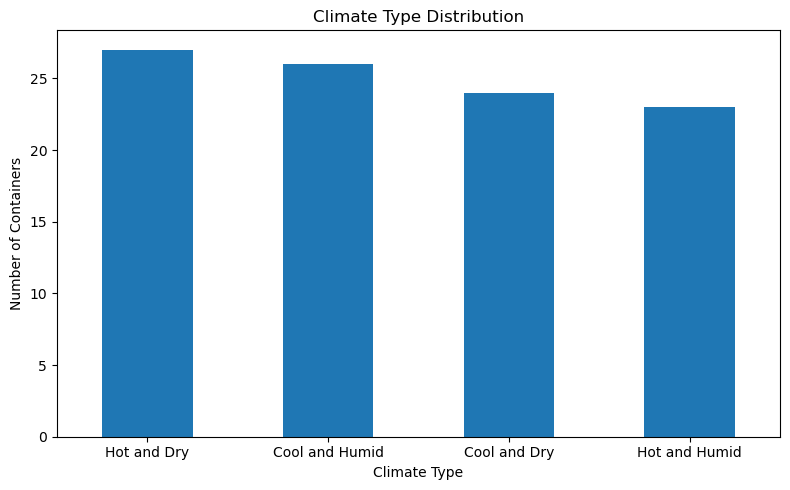

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

climate_counts.plot(kind="bar")

plt.xlabel("Climate Type")
plt.ylabel("Number of Containers")
plt.title("Climate Type Distribution")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [39]:
# View containers grouped by climate type

climate_groups = (
    climate_profile
    .reset_index()
    .sort_values(["Climate_Type", "Temperature_C"], ascending=[True, False])
)

display(climate_groups)

,Container_ID,Temperature_C,Humidity_Percent,Climate_Type
83,CONT_0084,26.146,48.12,Cool and Dry
31,CONT_0032,26.022,33.34,Cool and Dry
36,CONT_0037,25.590,49.18,Cool and Dry
89,CONT_0090,25.490,47.78,Cool and Dry
40,CONT_0041,25.408,47.86,Cool and Dry
...,...,...,...,...
22,CONT_0023,27.474,65.56,Hot and Humid
59,CONT_0060,27.398,56.46,Hot and Humid
4,CONT_0005,27.394,70.22,Hot and Humid
42,CONT_0043,27.288,69.22,Hot and Humid


In [40]:
# Compare average temperature and humidity by climate type

climate_summary = (
    climate_profile
    .groupby("Climate_Type")
    .agg({
        "Temperature_C": "mean",
        "Humidity_Percent": "mean"
    })
    .round(2)
)

display(climate_summary)

,Temperature_C,Humidity_Percent
Climate_Type,,
Cool and Dry,23.19,43.85
Cool and Humid,20.51,70.18
Hot and Dry,32.61,34.81
Hot and Humid,29.00,73.21


In [41]:
# Find the temperature range across containers

highest_temp_container = climate_profile["Temperature_C"].idxmax()
lowest_temp_container = climate_profile["Temperature_C"].idxmin()

highest_temp = climate_profile.loc[highest_temp_container, "Temperature_C"]
lowest_temp = climate_profile.loc[lowest_temp_container, "Temperature_C"]

temperature_difference = highest_temp - lowest_temp

print("Highest average temperature:")
print(highest_temp_container, "-", round(highest_temp, 2), "°C")

print("\nLowest average temperature:")
print(lowest_temp_container, "-", round(lowest_temp, 2), "°C")

print("\nTemperature difference between containers:",
      round(temperature_difference, 2), "°C")

Highest average temperature:
CONT_0077 - 42.46 °C

Lowest average temperature:
CONT_0082 - 3.75 °C

Temperature difference between containers: 38.71 °C


In [42]:
# Compare the hottest and coldest containers

comparison = climate_profile.loc[
    [highest_temp_container, lowest_temp_container],
    ["Temperature_C", "Humidity_Percent", "Climate_Type"]
].round(2)

display(comparison)

,Temperature_C,Humidity_Percent,Climate_Type
Container_ID,,,
CONT_0077,42.46,5.58,Hot and Dry
CONT_0082,3.75,91.72,Cool and Humid


In [43]:
# Calculate the difference from the overall climate averages

climate_comparison = climate_profile.copy()

climate_comparison["Temperature_Difference"] = (
    climate_comparison["Temperature_C"] - average_temp
).abs()

climate_comparison["Humidity_Difference"] = (
    climate_comparison["Humidity_Percent"] - average_humidity
).abs()

display(
    climate_comparison.sort_values(
        ["Temperature_Difference", "Humidity_Difference"],
        ascending=False
    ).head(10)
)

,Temperature_C,Humidity_Percent,Climate_Type,Temperature_Difference,Humidity_Difference
Container_ID,,,,,
CONT_0082,3.752,91.72,Cool and Humid,22.62088,36.7124
CONT_0077,42.462,5.58,Hot and Dry,16.08912,49.4276
CONT_0013,42.170,11.32,Hot and Dry,15.79712,43.6876
CONT_0073,10.662,81.76,Cool and Humid,15.71088,26.7524
CONT_0091,12.712,79.78,Cool and Humid,13.66088,24.7724
CONT_0010,38.860,30.84,Hot and Dry,12.48712,24.1676
CONT_0052,38.388,27.88,Hot and Dry,12.01512,27.1276
CONT_0080,38.112,32.12,Hot and Dry,11.73912,22.8876
CONT_0075,14.984,55.06,Cool and Humid,11.38888,0.0524


In [44]:
# Count containers in each climate type

climate_type_counts = (
    climate_profile["Climate_Type"]
    .value_counts()
    .sort_index()
)

print("Containers by climate type:")
display(climate_type_counts)

Containers by climate type:


Climate_Type
Cool and Dry      24
Cool and Humid    26
Hot and Dry       27
Hot and Humid     23
Name: count, dtype: int64

In [45]:
# Top 5 hottest containers

hottest_containers = climate_profile.sort_values(
    "Temperature_C",
    ascending=False
).head(5)

print("Top 5 Hottest Containers:")
display(hottest_containers.round(2))

Top 5 Hottest Containers:


,Temperature_C,Humidity_Percent,Climate_Type
Container_ID,,,
CONT_0077,42.46,5.58,Hot and Dry
CONT_0013,42.17,11.32,Hot and Dry
CONT_0010,38.86,30.84,Hot and Dry
CONT_0052,38.39,27.88,Hot and Dry
CONT_0080,38.11,32.12,Hot and Dry


In [46]:
# Top 5 most humid containers

most_humid_containers = climate_profile.sort_values(
    "Humidity_Percent",
    ascending=False
).head(5)

print("Top 5 Most Humid Containers:")
display(most_humid_containers.round(2))

Top 5 Most Humid Containers:


,Temperature_C,Humidity_Percent,Climate_Type
Container_ID,,,
CONT_0025,23.04,94.60,Cool and Humid
CONT_0082,3.75,91.72,Cool and Humid
CONT_0056,22.73,89.96,Cool and Humid
CONT_0034,25.56,89.50,Cool and Humid
CONT_0045,25.29,88.22,Cool and Humid


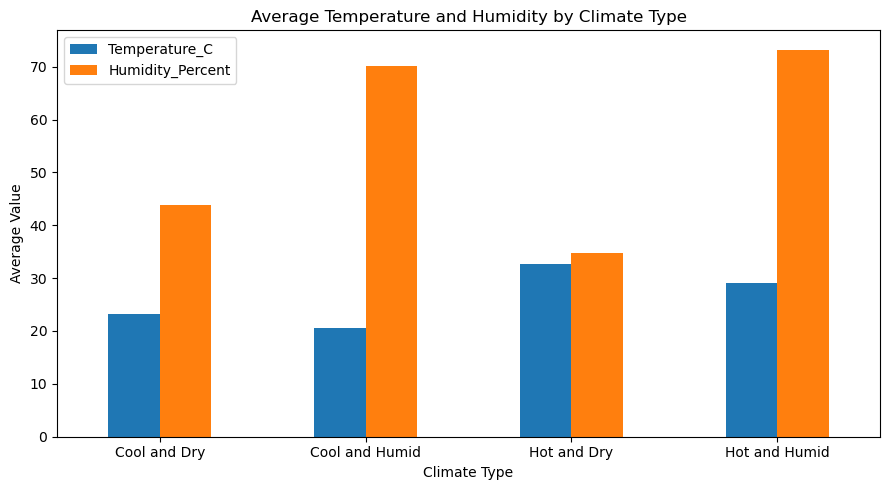

In [47]:
# Plot climate type comparison

climate_summary.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Climate Type")
plt.ylabel("Average Value")
plt.title("Average Temperature and Humidity by Climate Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
# Calculate climate variation score

climate_variation = climate_profile.copy()

climate_variation["Temperature_Difference"] = (
    climate_variation["Temperature_C"] - average_temp
).abs()

climate_variation["Humidity_Difference"] = (
    climate_variation["Humidity_Percent"] - average_humidity
).abs()

climate_variation["Variation_Score"] = (
    climate_variation["Temperature_Difference"] +
    climate_variation["Humidity_Difference"]
)

climate_variation = climate_variation.sort_values(
    "Variation_Score",
    ascending=False
)

display(climate_variation.head(10).round(2))

,Temperature_C,Humidity_Percent,Climate_Type,Temperature_Difference,Humidity_Difference,Variation_Score
Container_ID,,,,,,
CONT_0077,42.46,5.58,Hot and Dry,16.09,49.43,65.52
CONT_0013,42.17,11.32,Hot and Dry,15.80,43.69,59.48
CONT_0082,3.75,91.72,Cool and Humid,22.62,36.71,59.33
CONT_0098,35.41,15.12,Hot and Dry,9.04,39.89,48.92
CONT_0025,23.04,94.60,Cool and Humid,3.33,39.59,42.93
CONT_0073,10.66,81.76,Cool and Humid,15.71,26.75,42.46
CONT_0078,31.13,18.24,Hot and Dry,4.76,36.77,41.52
CONT_0055,22.32,19.52,Cool and Dry,4.05,35.49,39.54
CONT_0052,38.39,27.88,Hot and Dry,12.02,27.13,39.14


In [49]:
# Find containers with similar climate conditions

climate_similarity = climate_profile.copy()

climate_similarity["Climate_Profile"] = (
    climate_similarity["Temperature_C"].round(1).astype(str)
    + "°C, "
    + climate_similarity["Humidity_Percent"].round(1).astype(str)
    + "%"
)

display(
    climate_similarity[
        ["Temperature_C", "Humidity_Percent", "Climate_Type", "Climate_Profile"]
    ].head(10)
)

,Temperature_C,Humidity_Percent,Climate_Type,Climate_Profile
Container_ID,,,,
CONT_0001,26.556,20.70,Hot and Dry,"26.6°C, 20.7%"
CONT_0002,22.864,55.12,Cool and Humid,"22.9°C, 55.1%"
CONT_0003,29.186,82.80,Hot and Humid,"29.2°C, 82.8%"
CONT_0004,20.134,62.50,Cool and Humid,"20.1°C, 62.5%"
CONT_0005,27.394,70.22,Hot and Humid,"27.4°C, 70.2%"
CONT_0006,27.378,53.72,Hot and Dry,"27.4°C, 53.7%"
CONT_0007,22.148,77.06,Cool and Humid,"22.1°C, 77.1%"
CONT_0008,29.486,73.58,Hot and Humid,"29.5°C, 73.6%"
CONT_0009,30.316,27.72,Hot and Dry,"30.3°C, 27.7%"


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Select climate measurements
climate_features = climate_profile[
    ["Temperature_C", "Humidity_Percent"]
]

# Standardize the values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(climate_features)

# Calculate distance between containers
distance_matrix = euclidean_distances(scaled_features)

print("Climate similarity calculation completed.")
print("Number of containers compared:", len(climate_features))

Climate similarity calculation completed.
Number of containers compared: 100


In [51]:
# Find the most similar container for each container

similar_pairs = []

for i, container in enumerate(climate_features.index):
    distances = distance_matrix[i].copy()
    
    # Ignore the container itself
    distances[i] = float("inf")
    
    nearest_index = distances.argmin()
    nearest_container = climate_features.index[nearest_index]
    
    similar_pairs.append({
        "Container_ID": container,
        "Similar_Container": nearest_container,
        "Climate_Distance": distances[nearest_index]
    })

similarity_df = pd.DataFrame(similar_pairs)

display(similarity_df.head(10).round(3))

,Container_ID,Similar_Container,Climate_Distance
0,CONT_0001,CONT_0046,0.372
1,CONT_0002,CONT_0027,0.028
2,CONT_0003,CONT_0088,0.031
3,CONT_0004,CONT_0097,0.097
4,CONT_0005,CONT_0043,0.052
5,CONT_0006,CONT_0012,0.074
6,CONT_0007,CONT_0064,0.215
7,CONT_0008,CONT_0071,0.085
8,CONT_0009,CONT_0094,0.250
9,CONT_0010,CONT_0080,0.136


In [52]:
# Find the closest climate pairs

closest_pairs = similarity_df.sort_values(
    "Climate_Distance"
).head(10)

print("Top 10 Most Similar Climate Pairs:")
display(closest_pairs.round(3))

Top 10 Most Similar Climate Pairs:


,Container_ID,Similar_Container,Climate_Distance
48,CONT_0049,CONT_0024,0.010
23,CONT_0024,CONT_0049,0.010
40,CONT_0041,CONT_0090,0.014
89,CONT_0090,CONT_0041,0.014
32,CONT_0033,CONT_0011,0.014
10,CONT_0011,CONT_0033,0.014
60,CONT_0061,CONT_0086,0.017
85,CONT_0086,CONT_0061,0.017
49,CONT_0050,CONT_0059,0.021
58,CONT_0059,CONT_0050,0.021


In [53]:
# Remove reverse duplicates and find unique similar pairs

unique_pairs = similarity_df.copy()

unique_pairs["Pair"] = unique_pairs.apply(
    lambda row: tuple(sorted([row["Container_ID"], row["Similar_Container"]])),
    axis=1
)

unique_pairs = (
    unique_pairs
    .drop_duplicates("Pair")
    .sort_values("Climate_Distance")
)

print("Top 10 unique similar climate pairs:")
display(
    unique_pairs[
        ["Container_ID", "Similar_Container", "Climate_Distance"]
    ].head(10).round(3)
)

Top 10 unique similar climate pairs:


,Container_ID,Similar_Container,Climate_Distance
23,CONT_0024,CONT_0049,0.010
40,CONT_0041,CONT_0090,0.014
10,CONT_0011,CONT_0033,0.014
60,CONT_0061,CONT_0086,0.017
49,CONT_0050,CONT_0059,0.021
1,CONT_0002,CONT_0027,0.028
2,CONT_0003,CONT_0088,0.031
28,CONT_0029,CONT_0086,0.033
82,CONT_0083,CONT_0096,0.044
17,CONT_0018,CONT_0054,0.046


In [54]:
# Compare the actual climate conditions of the closest pairs

pair_comparison = []

for _, row in unique_pairs.head(10).iterrows():
    container1 = row["Container_ID"]
    container2 = row["Similar_Container"]

    data1 = climate_profile.loc[container1]
    data2 = climate_profile.loc[container2]

    pair_comparison.append({
        "Container_1": container1,
        "Container_2": container2,
        "Temp_1": round(data1["Temperature_C"], 2),
        "Temp_2": round(data2["Temperature_C"], 2),
        "Humidity_1": round(data1["Humidity_Percent"], 2),
        "Humidity_2": round(data2["Humidity_Percent"], 2),
        "Climate_Distance": round(row["Climate_Distance"], 3)
    })

pair_comparison_df = pd.DataFrame(pair_comparison)

display(pair_comparison_df)

,Container_1,Container_2,Temp_1,Temp_2,Humidity_1,Humidity_2,Climate_Distance
0,CONT_0024,CONT_0049,24.11,24.14,28.68,28.86,0.010
1,CONT_0041,CONT_0090,25.41,25.49,47.86,47.78,0.014
2,CONT_0011,CONT_0033,27.35,27.43,44.72,44.88,0.014
3,CONT_0061,CONT_0086,22.22,22.23,53.86,53.52,0.017
4,CONT_0050,CONT_0059,36.23,36.10,42.26,42.16,0.021
5,CONT_0002,CONT_0027,22.86,22.98,55.12,55.54,0.028
6,CONT_0003,CONT_0088,29.19,29.07,82.80,82.30,0.031
7,CONT_0029,CONT_0086,22.11,22.23,52.96,53.52,0.033
8,CONT_0083,CONT_0096,23.34,23.60,55.80,55.58,0.044
9,CONT_0018,CONT_0054,28.34,28.37,80.38,81.32,0.046


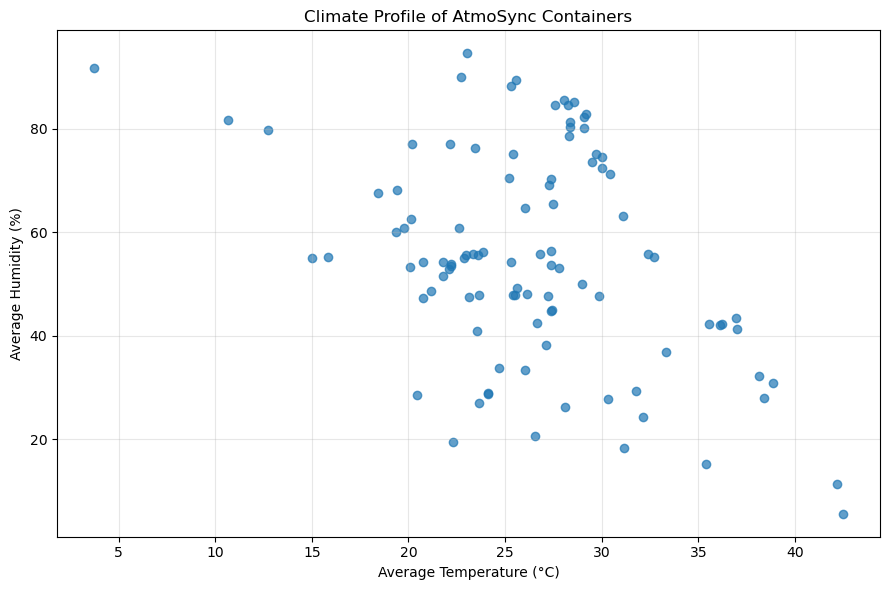

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    climate_profile["Temperature_C"],
    climate_profile["Humidity_Percent"],
    alpha=0.7
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Average Humidity (%)")
plt.title("Climate Profile of AtmoSync Containers")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# Climate summary by climate type

climate_summary = (
    climate_profile
    .groupby("Climate_Type")
    .agg({
        "Temperature_C": "mean",
        "Humidity_Percent": "mean"
    })
    .round(2)
)

print("Average Temperature and Humidity by Climate Type:")
display(climate_summary)

Average Temperature and Humidity by Climate Type:


,Temperature_C,Humidity_Percent
Climate_Type,,
Cool and Dry,23.19,43.85
Cool and Humid,20.51,70.18
Hot and Dry,32.61,34.81
Hot and Humid,29.00,73.21


In [57]:
# Final AtmoSync Key Insights

print("ATMOSYNC KEY INSIGHTS")
print("----------------------")

print("Total containers:", atmosync_df["Container_ID"].nunique())
print("Total records:", len(atmosync_df))

print("\nOverall Average Conditions:")
print("Average Temperature:", round(atmosync_df["Temperature_C"].mean(), 2), "°C")
print("Average Humidity:", round(atmosync_df["Humidity_Percent"].mean(), 2), "%")

hottest = climate_profile["Temperature_C"].idxmax()
coldest = climate_profile["Temperature_C"].idxmin()

print("\nTemperature Extremes:")
print(
    "Hottest container:",
    hottest,
    "-",
    round(climate_profile.loc[hottest, "Temperature_C"], 2),
    "°C"
)

print(
    "Coldest container:",
    coldest,
    "-",
    round(climate_profile.loc[coldest, "Temperature_C"], 2),
    "°C"
)

print("\nClimate Type Distribution:")
display(
    climate_profile["Climate_Type"]
    .value_counts()
    .to_frame("Container_Count")
)

print("\nTemperature-Humidity Correlation:",
      round(
          atmosync_df["Temperature_C"].corr(
              atmosync_df["Humidity_Percent"]
          ),
          2
      ))

ATMOSYNC KEY INSIGHTS
----------------------
Total containers: 100
Total records: 5000

Overall Average Conditions:
Average Temperature: 26.37 °C
Average Humidity: 55.01 %

Temperature Extremes:
Hottest container: CONT_0077 - 42.46 °C
Coldest container: CONT_0082 - 3.75 °C

Climate Type Distribution:


,Container_Count
Climate_Type,
Hot and Dry,27
Cool and Humid,26
Cool and Dry,24
Hot and Humid,23



Temperature-Humidity Correlation: -0.47
